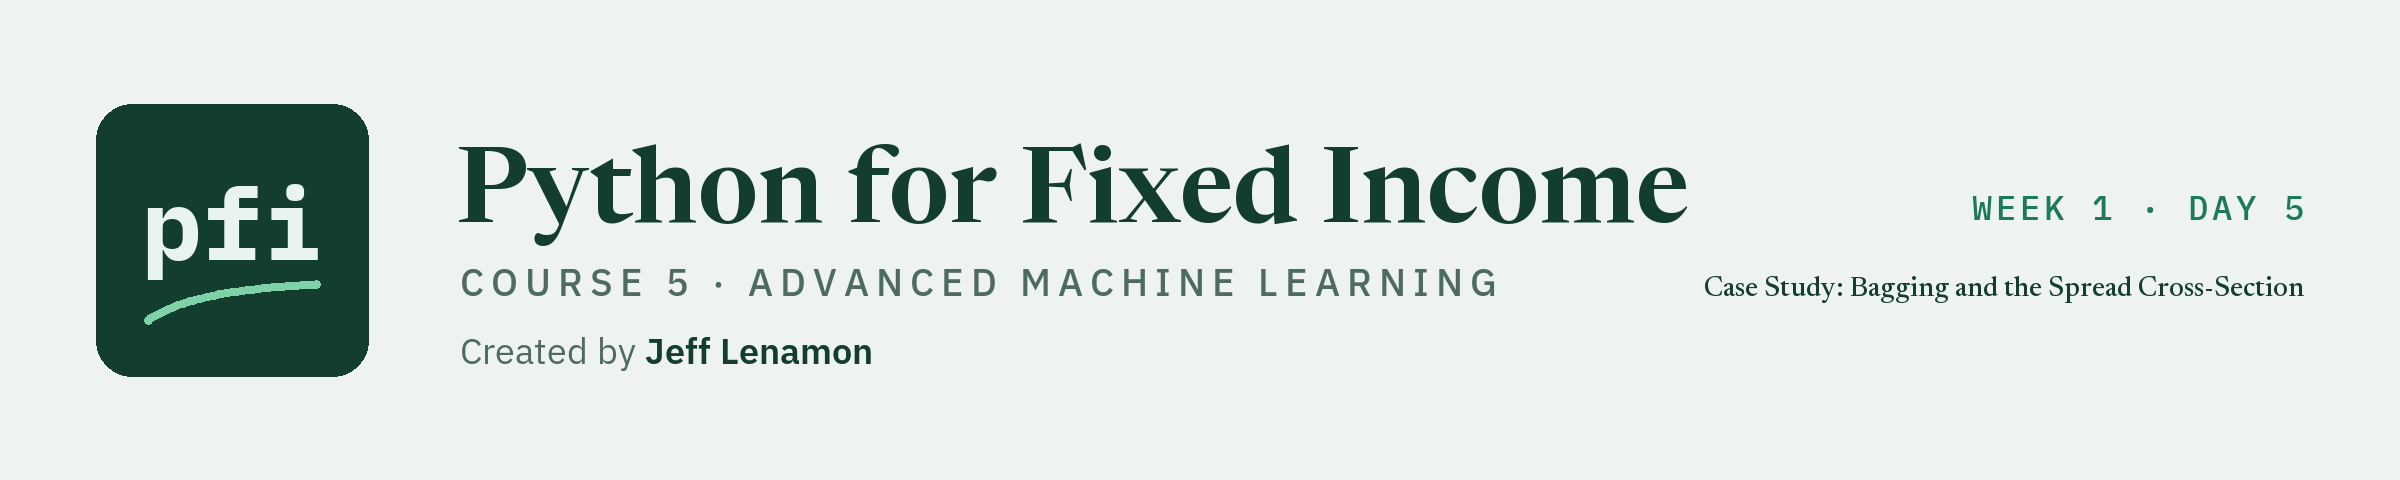

# Case Study: Bagging and the Spread Cross-Section

Week 1, Day 5. Week 1 ends with a forest fitted to a number instead of a class, and a case study: on the course's synthetic bonds, does a forest describe the spread cross-section better than Course 4's straight-line model, and where does it fail?

**Data:** `benchmark.csv` and `ratings.csv`, 821 bonds of invented issuers: **synthetic**, made for this course by `tools/make_holdings.py`. No real issuer, price, or spread.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course5_advanced_ml/week1/day5/05_case_study_bagging_and_the_spread_cross_section.ipynb)

Days 1 to 4 fitted trees and forests to the card file, where the output is a probability. Today a forest fits a number: the log of a bond's OAS. The morning is two short hands-on sections: regression trees and forests on the benchmark bonds (5.1), and the course's threshold rule moved off the validation rows of the card file (5.2), so week 2 chooses thresholds the same way. The afternoon is a case study on the benchmark: OLS, a tree, and a forest compared on the same bonds, the same folds, and the same metric, and a closing section on what the model shows and where it fails.

**The benchmark rules.**

* **The bonds are synthetic.** `benchmark.csv` holds 821 bonds of invented issuers, and their spreads were made by the course's generator, `tools/make_holdings.py` (read in this course, never run). Nothing here describes a real issuer, a real price, or a real market.
* **Course 4's split, rebuilt.** Course 4 split the bonds 75/25 and reported on its 206 test bonds every day of its week 1. By day 1's test-row rule, Course 5 never scores them: `ensemblekit.course4_bench_rows` returns only the 615 training bonds, and every number on the benchmark today comes from inside them.
* **A model's output is described.** A fitted value is the model's spread for a bond with these characteristics, and a residual is the part of a bond's spread the model misses. Neither is a fair value, and no output here says a bond is cheap or rich.

**The card rules, for section 5.2.** The card file is real, Taiwan in 2005, and consumer credit there differs from US credit. The four person columns are never features, and no output is grouped by them. Course 4's split is rebuilt with its 6,000 test rows closed (day 1, section 1.2). A model's output is the model probability of default in this file, or a flag at a threshold, and no output of either kind is a credit decision for any person.

Today you will:

1. Fit a regression tree and see that each leaf gives the mean log spread of its bonds.
2. Fit a `RandomForestRegressor` and read its out-of-bag score, which for a regressor is R-squared.
3. Add `course4_bench_rows` and `oof_threshold` to `ensemblekit.py`, with their tests.
4. Choose a card threshold for recall 0.70 from out-of-fold probabilities on the training rows, and report it on the validation rows.
5. Compare OLS, a depth-4 tree, and a 300-tree forest on the benchmark by five-fold MAE in bp, without and with coupon.
6. Split the folds by issuer and measure what that costs each model.
7. Write what the model shows, and where it fails.

Q. Set up today's work folder: the thread settings, the seed, the benchmark files, and the card file.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, scikit-learn, XGBoost, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("imblearn", "imbalanced-learn"), ("shap", "shap"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course5_advanced_ml/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "xgboost": "3.4.1", "lightgbm": "4.7.0", "imbalanced-learn": "0.14.2", "shap": "0.52.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course5_05_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, xgboost 3.4.1, lightgbm 4.7.0, imbalanced-learn 0.14.2, shap 0.52.0, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course5_05_eemxnj_k, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, credit_card_default.csv
SEED = 42


Q. Write `mlkit.py`, Course 4's complete module, unchanged. `ensemblekit` imports it.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `ensemblekit.py` and `test_ensemblekit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")

Writing ensemblekit.py


In [4]:
%%writefile test_ensemblekit.py
"""Tests for ensemblekit.py.

Expected values come from scikit-learn, XGBoost, LightGBM, imbalanced-learn, or SHAP on the same inputs, from
Course 4's published numbers, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from functools import cache
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import ensemblekit

HERE = Path(__file__).resolve().parent
SEED = 42


@cache
def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, read once per test run."""
    return pd.read_csv(HERE / "credit_card_default.csv")


@cache
def card_rows() -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's training and validation rows of the card file."""
    return ensemblekit.course4_card_rows(read_card())


def card_small(n: int = 3_000) -> tuple[pd.DataFrame, pd.Series]:
    """The first n of Course 4's training rows, for tests that fit many models and must stay fast."""
    X_train, _, y_train, _ = card_rows()
    return X_train.iloc[:n], y_train.iloc[:n]


def course4_card_test_labels() -> set:
    """The row labels of Course 4's card test set, recomputed with Course 4's own call."""
    card = read_card()
    y = card[ensemblekit.CARD_TARGET]
    _, X_test = train_test_split(card, test_size=0.2, stratify=y, random_state=SEED)
    return set(X_test.index)


def test_course4_card_rows_counts():
    X_train, X_valid, y_train, y_valid = card_rows()
    assert (len(X_train), len(X_valid), len(y_train), len(y_valid)) == (18_000, 6_000, 18_000, 6_000)
    assert list(X_train.columns) == ensemblekit.CARD_FEATURES
    for person in ("SEX", "EDUCATION", "MARRIAGE", "AGE", "ID"):
        assert person not in X_train.columns
    with pytest.raises(ValueError):
        ensemblekit.course4_card_rows(read_card().iloc[:100])


def test_course4_card_rows_closed_rows():
    X_train, X_valid, _, _ = card_rows()
    closed = course4_card_test_labels()
    assert len(closed) == 6_000
    assert not closed & set(X_train.index)
    assert not closed & set(X_valid.index)


def test_course4_card_rows_reproduces_logistic():
    X_train, X_valid, y_train, y_valid = card_rows()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    # Course 4 day 10's validation ROC AUC for the scaled logistic regression
    assert round(roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]), 4) == 0.7190


def test_bootstrap_positions_with_replacement():
    drawn = ensemblekit.bootstrap_positions(1_000)
    assert drawn.shape == (1_000,)
    assert drawn.min() >= 0 and drawn.max() <= 999
    # with replacement: some rows twice, so fewer distinct positions than rows
    assert len(np.unique(drawn)) < 1_000
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_positions(0)


def test_bootstrap_positions_seeded():
    first = ensemblekit.bootstrap_positions(500, seed=SEED)
    assert np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=SEED))
    assert np.array_equal(first, np.random.default_rng(SEED).integers(0, 500, 500))
    assert not np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=7))


def test_out_of_bag_hand():
    # rows 0 to 5; the sample drew 0, 0, 2, 5, 5, 5: rows 1, 3, 4 were never drawn
    left_out = ensemblekit.out_of_bag(6, np.array([0, 0, 2, 5, 5, 5]))
    assert left_out.tolist() == [1, 3, 4]
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([0, 6]))
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([], dtype=int))


def test_out_of_bag_share_near_e():
    n = 18_000
    drawn = ensemblekit.bootstrap_positions(n)
    left_out = ensemblekit.out_of_bag(n, drawn)
    # no row is both drawn and out of bag
    assert not set(left_out.tolist()) & set(drawn.tolist())
    # (1 - 1/n)^n tends to 1/e = 0.3679
    assert abs(len(left_out) / n - np.exp(-1)) < 0.01


from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


def small_bagging(n_estimators: int = 10, oob: bool = False) -> tuple[BaggingClassifier, pd.DataFrame, pd.Series]:
    X, y = card_small()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=n_estimators,
                                oob_score=oob, random_state=SEED, n_jobs=1)
    return bagging.fit(X, y), X, y


def test_bagged_proba_matches_sklearn():
    bagging, X, _ = small_bagging()
    _, X_valid, _, _ = card_rows()
    assert ensemblekit.bagged_proba(bagging, X_valid) == pytest.approx(bagging.predict_proba(X_valid)[:, 1], abs=1e-12)
    # also with a random half of the columns per tree, so estimators_features_ matters
    X, y = card_small()
    half = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, max_features=0.5,
                             random_state=SEED, n_jobs=1).fit(X, y)
    assert ensemblekit.bagged_proba(half, X_valid) == pytest.approx(half.predict_proba(X_valid)[:, 1], abs=1e-12)


def test_bagged_proba_rejects_unfitted():
    with pytest.raises(ValueError, match="not fitted"):
        ensemblekit.bagged_proba(BaggingClassifier(random_state=SEED), card_small()[0])


def test_oob_auc_matches_roc_auc():
    bagging, _, y = small_bagging(n_estimators=40, oob=True)
    assert ensemblekit.oob_auc(bagging, y) == pytest.approx(roc_auc_score(y, bagging.oob_decision_function_[:, 1]),
                                                            abs=1e-12)
    # oob_score_ is accuracy, a different number
    assert ensemblekit.oob_auc(bagging, y) != pytest.approx(bagging.oob_score_, abs=1e-3)


def test_oob_auc_requires_oob_score():
    bagging, _, y = small_bagging()
    with pytest.raises(ValueError, match="oob_score=True"):
        ensemblekit.oob_auc(bagging, y)


from types import SimpleNamespace

from sklearn.ensemble import RandomForestClassifier


class StandInTree:
    """A stand-in for a fitted tree: its class-1 output is the first column plus a constant."""

    def __init__(self, shift: float):
        self.shift = shift

    def predict_proba(self, values: np.ndarray) -> np.ndarray:
        p = values[:, 0] / 10 + self.shift
        return np.column_stack([1 - p, p])


def test_tree_correlation_hand():
    X = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0], "b": [0.0, 0.0, 1.0, 1.0]})
    # two outputs that differ by a constant are perfectly correlated
    forest = SimpleNamespace(estimators_=[StandInTree(0.1), StandInTree(0.3)])
    assert ensemblekit.tree_correlation(forest, X) == pytest.approx(1.0, abs=1e-12)


def test_tree_correlation_forest_below_bagging():
    X, y = card_small()
    _, X_valid, _, _ = card_rows()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, random_state=SEED,
                                n_jobs=1).fit(X, y)
    forest = RandomForestClassifier(n_estimators=10, random_state=SEED, n_jobs=1).fit(X, y)
    assert forest.estimators_[0].max_features == "sqrt"
    assert ensemblekit.tree_correlation(forest, X_valid) < ensemblekit.tree_correlation(bagging, X_valid)


def test_tree_correlation_rejects_one_tree():
    X, y = card_small(500)
    forest = RandomForestClassifier(n_estimators=1, random_state=SEED, n_jobs=1).fit(X, y)
    with pytest.raises(ValueError, match="at least two trees"):
        ensemblekit.tree_correlation(forest, X)


from sklearn.inspection import permutation_importance


@cache
def forest_with_noise() -> tuple[RandomForestClassifier, pd.DataFrame, pd.Series]:
    """A 50-tree forest with 20-row leaves on 3,000 training rows plus a column of random numbers, and 2,000
    validation rows with their own random column."""
    X, y = card_small()
    _, X_valid, _, y_valid = card_rows()
    rng = np.random.default_rng(SEED)
    X = X.assign(noise=rng.normal(size=len(X)))
    X_valid = X_valid.iloc[:2_000].assign(noise=rng.normal(size=2_000))
    forest = RandomForestClassifier(n_estimators=50, min_samples_leaf=20, random_state=SEED, n_jobs=1).fit(X, y)
    return forest, X_valid, y_valid.iloc[:2_000]


def test_importance_table_columns_and_ranks():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    assert list(table.columns) == ["impurity", "permutation", "permutation_sd", "impurity_rank", "permutation_rank"]
    assert set(table.index) == set(X_valid.columns)
    assert table["impurity"].sum() == pytest.approx(1.0, abs=1e-12)
    assert table["permutation"].is_monotonic_decreasing
    assert table["permutation_rank"].iloc[0] == 1
    assert table.loc[table["impurity"].idxmax(), "impurity_rank"] == 1


def test_importance_table_matches_permutation_importance():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid, n_repeats=3)
    direct = permutation_importance(forest, X_valid, y_valid, scoring="roc_auc", n_repeats=3, random_state=SEED,
                                    n_jobs=1)
    expected = pd.Series(direct.importances_mean, index=X_valid.columns)
    assert table["permutation"].to_numpy() == pytest.approx(expected[table.index].to_numpy(), abs=1e-12)


def test_importance_table_noise_near_zero():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    # on unseen rows, shuffling a column of random numbers costs (almost) nothing
    assert abs(table.loc["noise", "permutation"]) < 0.01
    assert table.loc["PAY_0", "permutation"] > 10 * abs(table.loc["noise", "permutation"])


def test_importance_table_rejects_model_without_importances():
    X, y = card_small(500)
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X, y)
    with pytest.raises(ValueError, match="feature_importances_"):
        ensemblekit.importance_table(model, X, y)

Writing test_ensemblekit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)

# the functions and classes defined in ensemblekit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(ensemblekit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "ensemblekit" and not name.startswith("_")]
print(f"ensemblekit functions: {functions}")

ensemblekit functions: ['course4_card_rows', 'bootstrap_positions', 'out_of_bag', 'bagged_proba', 'oob_auc', 'tree_correlation', 'importance_table']


* The setup copies three data files: the benchmark and its ratings table for today's case study, and the card file for section 5.2 and for the tests days 1 to 4 wrote.

## 5.1 Regression Trees and Forests

A tree for a number works as the card trees did, with one change: a leaf gives the **mean** of its training rows' target, not a share of defaults, and a split is chosen to make the squared errors around the two means as small as it can. A forest of such trees averages their means.

The first function of the day rebuilds Course 4's training bonds, as `course4_card_rows` did for the card file.

Q. Add `course4_bench_rows` to `ensemblekit.py`. Read the docstring first.

In [6]:
%%writefile -a ensemblekit.py


from sklearn.model_selection import cross_val_predict  # out-of-fold outputs, one per row


def course4_bench_rows(bench: pd.DataFrame, ratings: pd.DataFrame) -> pd.DataFrame:
    """Course 4's 615 training bonds of the synthetic benchmark, without its 206 test bonds.

    Inputs: bench, the 821 bonds of benchmark.csv; ratings, ratings.csv (rating and score).
    Output: the 615 training bonds with every column of bench plus score (the rating's number, 1 = AAA),
    log_oas (natural log of oas in bp), years (days from as_of_date to maturity / 365.25), and amount_bn
    (amount_outstanding in billions), with bench's row labels. Course 4's 206 test bonds are never returned.
    Convention: Course 4's split, train_test_split(test_size=0.25, random_state=42) on the joined rows. The bonds
    and their spreads are invented by the course's generator.
    Raises ValueError if bench does not hold 821 bonds.
    """
    if len(bench) != 821:
        raise ValueError(f"bench must hold the 821 benchmark bonds, not {len(bench)}")
    # the rating's number, joined row for row (each rating appears once in ratings)
    frame = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    frame["log_oas"] = np.log(frame["oas"])
    dates = pd.to_datetime(frame["maturity"]) - pd.to_datetime(frame["as_of_date"])
    frame["years"] = dates.dt.days / 365.25
    frame["amount_bn"] = frame["amount_outstanding"] / 1e9
    # Course 4's split: the second part was its test set, dropped here
    train, _ = train_test_split(frame, test_size=0.25, random_state=42)
    return train

Appending to ensemblekit.py


* It joins each bond's rating number (`score`, 1 for AAA to 18 for CCC) and builds `log_oas`, `years`, and `amount_bn` as Course 4 day 5 did. Then it runs Course 4's split, `train_test_split(test_size=0.25, random_state=42)`, and keeps only the first part: the second, Course 4's test bonds, goes into `_` and is never returned.

Q. Add its test: the counts, the new columns, and no closed bond returned.

In [7]:
%%writefile -a test_ensemblekit.py


from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted


@cache
def bench_rows() -> pd.DataFrame:
    """Course 4's 615 training bonds."""
    return ensemblekit.course4_bench_rows(pd.read_csv(HERE / "benchmark.csv"), pd.read_csv(HERE / "ratings.csv"))


def test_course4_bench_rows_counts_and_closed():
    train = bench_rows()
    assert len(train) == 615
    assert {"score", "log_oas", "years", "amount_bn"} <= set(train.columns)
    assert train["log_oas"].to_numpy() == pytest.approx(np.log(train["oas"]).to_numpy(), abs=1e-12)
    # Course 4's test bonds, recomputed with Course 4's call on the file
    bench = pd.read_csv(HERE / "benchmark.csv")
    _, bench_test = train_test_split(bench, test_size=0.25, random_state=SEED)
    assert len(bench_test) == 206
    assert not set(bench_test["cusip"]) & set(train["cusip"])
    with pytest.raises(ValueError):
        ensemblekit.course4_bench_rows(bench.iloc[:800], pd.read_csv(HERE / "ratings.csv"))

Appending to test_ensemblekit.py


* The test recomputes Course 4's test bonds with Course 4's own call on the file, only to read their CUSIPs, and asserts none of them is among the bonds the function returns. It also checks the function refuses a file that is not the whole benchmark.

Q. Reload the module and run the tests.

In [8]:
# the file changed, so reload before using the new function
importlib.reload(ensemblekit)
print(f"course4_bench_rows in ensemblekit: {hasattr(ensemblekit, 'course4_bench_rows')}")

course4_bench_rows in ensemblekit: True


In [9]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...................                                                      [100%]
19 passed in 30.22s



* `19 passed`: the 18 tests days 1 to 4 wrote, and today's first.

Q. Load the benchmark and take Course 4's training bonds.

In [10]:
# the synthetic benchmark: invented issuers, spreads made by the course's generator
bench = pd.read_csv("benchmark.csv")
ratings = pd.read_csv("ratings.csv")

# Course 4's training bonds only; its test bonds are never returned
train = ensemblekit.course4_bench_rows(bench, ratings)
y = train["log_oas"]
print(f"{len(bench)} bonds in the file; {len(train)} training bonds returned; {len(bench) - len(train)} closed")
print(f"{train['ticker'].nunique()} issuers, {train['rating'].nunique()} ratings, {train['sector'].nunique()} sectors in the training bonds")
print(f"OAS from {train['oas'].min():,} bp to {train['oas'].max():,} bp")

821 bonds in the file; 615 training bonds returned; 206 closed
149 issuers, 18 ratings, 10 sectors in the training bonds
OAS from 15 bp to 2,074 bp


* 615 training bonds of 149 issuers, with all 18 ratings and all 10 sectors present. The spreads run from 15 bp to 2,074 bp, so every model today fits `log_oas`, the natural log of OAS, as Course 4 did, and every error is reported in bp after turning the log back with `exp`.

Q. Fit a depth-4 regression tree on four numbers: the rating's number, duration, years, and amount. What does a leaf give?

In [11]:
from sklearn.tree import DecisionTreeRegressor

# four numbers per bond; a tree needs no scaling
SIMPLE = ["score", "duration", "years", "amount_bn"]
tree = DecisionTreeRegressor(max_depth=4, random_state=SEED).fit(train[SIMPLE], y)
fitted_log = tree.predict(train[SIMPLE])

print(f"first question: {SIMPLE[tree.tree_.feature[0]]} <= {tree.tree_.threshold[0]}")
print(f"{tree.get_n_leaves()} leaves; {len(np.unique(fitted_log))} different fitted values")

# the leaf of the first bond, and the mean log spread of every training bond in that leaf
leaf = tree.apply(train[SIMPLE])
same_leaf = leaf == leaf[0]
print(f"first bond: {same_leaf.sum()} bonds share its leaf; their mean log_oas {y[same_leaf].mean():.6f}, "
      f"the tree's fitted value {fitted_log[0]:.6f}")
print(f"as a spread: fitted {np.exp(fitted_log[0]):.1f} bp, against its OAS of {train['oas'].iloc[0]} bp")

first question: score <= 9.5
16 leaves; 16 different fitted values
first bond: 56 bonds share its leaf; their mean log_oas 4.011076, the tree's fitted value 4.011076
as a spread: fitted 55.2 bp, against its OAS of 49 bp


* The tree asks first about `score`, the rating's number, at 9.5: in this file the rating separates spreads more than anything else, as Course 4 found. It has 16 leaves, so it gives only 16 different fitted values to 615 bonds.
* The first bond's leaf holds 56 training bonds, and the tree's fitted value for it is exactly their mean log spread. Its fitted spread is 55.2 bp, the model's spread for a bond with these characteristics; its OAS is 49 bp. Every bond in that leaf gets the same fitted spread.

Q. Fit a forest of 300 such trees, grown full, and ask for its out-of-bag score.

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 300 full-grown regression trees, each on a bootstrap sample; oob_score=True scores each bond with the trees that never saw it
forest = RandomForestRegressor(n_estimators=300, oob_score=True, random_state=SEED, n_jobs=1).fit(train[SIMPLE], y)

# for a regressor, oob_score_ is R-squared on log_oas, computed from oob_prediction_
print(f"oob_score_: {forest.oob_score_:.4f}")
print(f"R-squared of oob_prediction_ against log_oas: {r2_score(y, forest.oob_prediction_):.4f}")

# the same out-of-bag fitted values as an error in bp, beside the forest's error on the bonds it was fitted on
oob_mae = mlkit.regression_metrics(np.exp(y), np.exp(forest.oob_prediction_))["mae"]
fit_mae = mlkit.regression_metrics(np.exp(y), np.exp(forest.predict(train[SIMPLE])))["mae"]
print(f"MAE: {oob_mae:.1f} bp out of bag, {fit_mae:.1f} bp on the bonds each tree was fitted on")

oob_score_: 0.8816
R-squared of oob_prediction_ against log_oas: 0.8816
MAE: 41.0 bp out of bag, 16.2 bp on the bonds each tree was fitted on


**Rows.** Every model on the benchmark in this notebook is fitted and scored inside Course 4's 615 training bonds, by out-of-bag rows or by five folds; Course 4's 206 test bonds are never scored in this course.

* For a regressor, `oob_score_` is the **R-squared** of the out-of-bag fitted values against `log_oas`: 0.8816, equal to `r2_score` on `oob_prediction_`. Day 2 found that for a classifier the same attribute is accuracy. The name is the same; what it measures depends on the model, so read the documentation, or check it as this cell does.
* Out of bag, the forest misses by 41.0 bp on average. On the bonds it was fitted on, the same forest misses by 16.2 bp, less than half as much: full trees fit their own rows closely, and only rows a tree never saw score it honestly. Every fitted value is the model's spread for a bond with these characteristics.

Q. Is the out-of-bag error close to an error from five folds?

In [13]:
from sklearn.model_selection import cross_val_predict

# five folds of the training bonds: each bond's fitted value from a forest fitted on the other four folds
folds = mlkit.cv_folds("regression")
fitted_cv = cross_val_predict(RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=1), train[SIMPLE], y,
                              cv=folds, n_jobs=1)
print(folds)
print(f"five folds: MAE {mlkit.regression_metrics(np.exp(y), np.exp(fitted_cv))['mae']:.1f} bp, R-squared {r2_score(y, fitted_cv):.4f}")
print(f"out of bag: MAE {oob_mae:.1f} bp, R-squared {forest.oob_score_:.4f}")

KFold(n_splits=5, random_state=42, shuffle=True)
five folds: MAE 40.6 bp, R-squared 0.8844
out of bag: MAE 41.0 bp, R-squared 0.8816


* Five folds give 40.6 bp and R-squared 0.8844; out of bag gives 41.0 bp and 0.8816. Close, from one fit instead of five. The two are not the same number: an out-of-bag value averages only the trees that left a bond out, about a third of the 300, and the fold forests were fitted on four fifths of the bonds.
* `mlkit.cv_folds("regression")` is Course 4's splitter, five shuffled folds with seed 42. The case study uses it for every model.

Q. Draw each bond's OAS against the forest's out-of-bag fitted spread.

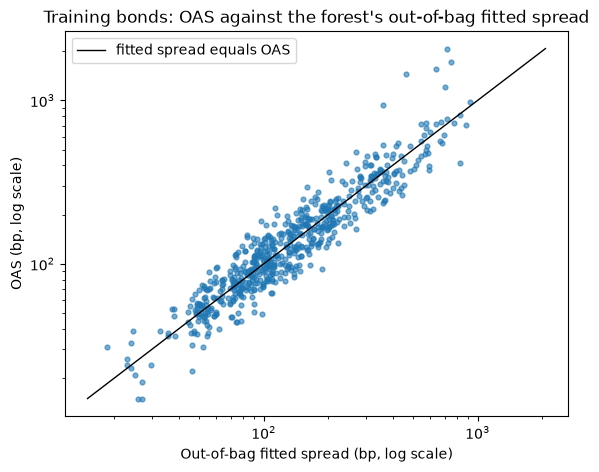

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(np.exp(forest.oob_prediction_), train["oas"], s=12, alpha=0.6)
line = [train["oas"].min(), train["oas"].max()]
ax.plot(line, line, color="black", linewidth=1, label="fitted spread equals OAS")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Training bonds: OAS against the forest's out-of-bag fitted spread")
ax.set_xlabel("Out-of-bag fitted spread (bp, log scale)")
ax.set_ylabel("OAS (bp, log scale)")
ax.legend()
plt.show()

* The bonds sit around the line across the whole range, with more scatter at the wide end. The fitted spreads stop well short of the widest OAS values: a forest's fitted value is an average of training bonds' log spreads, so it can never go beyond the widest bond it was fitted on, and an average of many leaves sits further inside. Section 5.9 comes back to this.

## 5.2 The Threshold Rule, Moved onto the Training Rows

Course 4's threshold rule is the highest threshold whose recall is at least 0.70 (`mlkit.threshold_for_recall`). Course 4 day 10 applied it to the card file's validation rows, and then reported on its test rows. Course 5 chooses nothing on the validation rows, so the rule needs other rows to choose on. The answer is the out-of-fold probabilities from day 1's idea, made with five folds: each training row gets a probability from a model fitted on the other four fifths, and the threshold is chosen on those. The validation rows then report a recall the threshold was not chosen to hit.

Q. Add `oof_threshold` to `ensemblekit.py`, and its two tests.

In [15]:
%%writefile -a ensemblekit.py


def oof_threshold(model, X, y, target_recall: float = 0.70, cv=None) -> tuple[float, np.ndarray]:
    """The course's threshold rule, applied to out-of-fold probabilities on the training rows.

    Inputs: model, an unfitted (or fitted) classifier with predict_proba; X, y, the training rows; target_recall,
    the share of defaults to catch; cv, a splitter (default mlkit.cv_folds(), stratified 5-fold, seed 42).
    Output: (threshold, proba): proba holds each training row's class-1 probability from the fold model that did
    not see it (cross_val_predict, n_jobs=1); threshold is mlkit.threshold_for_recall(y, proba, target_recall),
    the highest threshold whose out-of-fold recall is at least target_recall.
    Convention: the threshold is chosen on training rows only, so validation and test rows stay for reporting.
    cross_val_predict fits clones, so the caller's model is left as it was.
    Raises ValueError from mlkit.threshold_for_recall on a bad target or no row of class 1.
    """
    folds = cv if cv is not None else mlkit.cv_folds()
    proba = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
    return mlkit.threshold_for_recall(y, proba, target_recall), proba

Appending to ensemblekit.py


In [16]:
%%writefile -a test_ensemblekit.py


def test_oof_threshold_meets_recall():
    X, y = card_small()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    threshold, proba = ensemblekit.oof_threshold(model, X, y, target_recall=0.70)
    assert proba.shape == (len(X),)
    flagged = proba >= threshold
    assert flagged[y.to_numpy() == 1].mean() >= 0.70
    # the next higher distinct probability would miss the target
    higher = np.unique(proba[proba > threshold])
    if higher.size:
        assert (proba >= higher[0])[y.to_numpy() == 1].mean() < 0.70


def test_oof_threshold_does_not_fit_callers_model():
    X, y = card_small(1_000)
    model = DecisionTreeClassifier(max_depth=3, random_state=SEED)
    ensemblekit.oof_threshold(model, X, y)
    with pytest.raises(NotFittedError):
        check_is_fitted(model)

Appending to test_ensemblekit.py


* `cross_val_predict(..., method="predict_proba")` returns, for every training row, the class-1 probability from the fold model that did not see it. The rule then runs on those, as Course 4's function, which `oof_threshold` calls rather than repeats.
* The first test checks the threshold meets the recall and that the next higher probability would miss it. The second checks the caller's model is left unfitted: `cross_val_predict` fits copies, never the model you pass.

Q. Reload and run all of today's tests.

In [17]:
importlib.reload(ensemblekit)
print(f"oof_threshold in ensemblekit: {hasattr(ensemblekit, 'oof_threshold')}")

oof_threshold in ensemblekit: True


In [18]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.....................                                                    [100%]
21 passed in 27.43s



* `21 passed`: the module's two new functions, tested.

Q. Choose a threshold for Course 4's logistic regression from out-of-fold probabilities on the training rows, then report it on the validation rows.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Course 4's card rows: training and validation only, the 19 model columns
card = pd.read_csv("credit_card_default.csv")
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)

# Course 4's logistic regression; the threshold is chosen from out-of-fold probabilities on the training rows
logistic = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
threshold_log, oof_log = ensemblekit.oof_threshold(logistic, X_train, y_train, target_recall=0.70)
print(f"threshold {threshold_log:.4f}; out-of-fold recall on the training rows {(oof_log >= threshold_log)[y_train == 1].mean():.4f}")

# fit on all training rows, then report on the validation rows, flagging at that threshold
proba_log = logistic.fit(X_train, y_train).predict_proba(X_valid)[:, 1]
valid = mlkit.classification_metrics(y_valid, (proba_log >= threshold_log).astype(int))
print(f"validation: ROC AUC {roc_auc_score(y_valid, proba_log):.4f}, recall {valid['recall']:.4f}, precision {valid['precision']:.4f}")

threshold 0.2047; out-of-fold recall on the training rows 0.7002
validation: ROC AUC 0.7190, recall 0.6956, precision 0.3319


**Rows.** Every model on the card file in this notebook is fitted on Course 4's 18,000 training rows, with its threshold chosen from out-of-fold probabilities inside them, and scored on Course 4's 6,000 validation rows; Course 4's 6,000 test rows are never scored in this course.

* The threshold, 0.2047, catches 0.7002 of the defaults in the training rows' out-of-fold probabilities, at least 0.70 as the rule asks. On the validation rows, which took no part in choosing it, the same threshold flags accounts with recall 0.6956 and precision 0.3319. Recall lands near 0.70 but not on it: that is what an honest number looks like when the threshold was chosen on other rows. The output is the model probability of default in this file; an account is flagged at threshold 0.2047.

Q. Do the same for a forest: 100 trees with leaves of at least 5 rows.

In [20]:
from sklearn.ensemble import RandomForestClassifier

# a forest of 100 trees with 5-row leaves, day 3's best leaf size, kept to 100 trees so five folds stay quick
card_forest = RandomForestClassifier(n_estimators=100, min_samples_leaf=5, random_state=SEED, n_jobs=1)
threshold_rf, oof_rf = ensemblekit.oof_threshold(card_forest, X_train, y_train, target_recall=0.70)
print(f"threshold {threshold_rf:.4f}; out-of-fold recall on the training rows {(oof_rf >= threshold_rf)[y_train == 1].mean():.4f}")

proba_rf = card_forest.fit(X_train, y_train).predict_proba(X_valid)[:, 1]
valid_rf = mlkit.classification_metrics(y_valid, (proba_rf >= threshold_rf).astype(int))
print(f"validation: ROC AUC {roc_auc_score(y_valid, proba_rf):.4f}, recall {valid_rf['recall']:.4f}, precision {valid_rf['precision']:.4f}")

threshold 0.1972; out-of-fold recall on the training rows 0.7002


validation: ROC AUC 0.7797, recall 0.6971, precision 0.4128


* The forest's threshold is 0.1972, not the logistic regression's 0.2047: each model's outputs sit on their own scale, so each gets its own threshold from its own out-of-fold probabilities. On the validation rows it flags with recall 0.6971 and precision 0.4128, higher precision than the logistic regression's 0.3319 at about the same recall, which is what its higher ROC AUC (0.7797 against 0.7190) says it can do.
* From today, every Course 5 threshold on the card file comes from `oof_threshold`: week 2 compares boosted models the same way.

## Case Study: Bagging and the Spread Cross-Section

### Context

Course 4 week 1 fitted straight-line models to the course's benchmark bonds: log OAS on rating, sector, duration, years, coupon, and size. Course 4 day 5 compared OLS, ridge, and lasso and found them within a fraction of a bp of each other; it also found that coupon partly restates the spread, and that splitting by issuer costs every model. A colleague now asks the week 1 question about the same bonds: **does an average of trees describe the spread cross-section better than the straight line, and where does it fail?** The bonds and spreads are synthetic, made by the course's generator, so every answer describes that recipe and can be checked against it.

### Objective

1. Compare three models on the same 615 training bonds, the same five folds, and the same metric: OLS (Course 4's pipeline), a depth-4 tree, and a 300-tree forest, by cross-validated MAE in bp with R-squared on `log_oas` beside it.
2. Do it without coupon and with coupon.
3. Split the folds by issuer and measure what that costs.
4. Check how much the folds move a number, so a difference between models can be read against it.
5. Close with what the model shows, and where it fails.

### Data dictionary

| Column | Meaning | Unit | Role |
| --- | --- | --- | --- |
| `oas` | option-adjusted spread, generated | bp | target, as `log_oas` |
| `log_oas` | natural log of `oas` | log of bp | target |
| `rating` | one of 18 levels, AAA to CCC | category | OLS feature, one indicator per level, reference A |
| `score` | the rating's number, 1 (AAA) to 18 (CCC) | rank | tree and forest feature |
| `sector` | one of 10 sectors | category | feature, one indicator per sector (OLS: reference Consumer) |
| `duration` | modified duration | years | feature |
| `years` | years to maturity from the as-of date, days / 365.25 | years | feature |
| `coupon` | annual coupon | percent | feature in the "with coupon" models only |
| `amount_bn` | amount outstanding | billions of dollars | feature |
| `ticker` | the issuer's code | category | groups for the split by issuer (section 5.7), never a feature |

### Exploration

Course 4 explored these bonds on its days 1 to 5: the spread against rating, duration against years, the log of OAS and its widest bonds, and the fitted rating effects beside the generator's table. The case study does not repeat that. Section 5.1 printed the counts it needs.

## 5.3 Preparation: Two Kinds of Input, One Set of Folds

OLS gets Course 4 day 5's pipeline unchanged: rating and sector as indicator columns with named reference levels, and the numbers scaled, all fitted inside the pipeline on each fold's fitting rows.

The trees get the same information in the form a tree can use. A tree asks one question at a time, so 17 rating indicators would make it ask "is the rating BB?" one level at a time; the rating's number lets it ask "is the rating worse than BBB-?" in one question. Sector has no order, so it stays as indicators. Trees need no scaling, so the numbers pass through as they are. Section 5.5 measures what this choice is worth.

Q. Write the two pipelines, the metric, and one function that scores a model on five folds.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import OneHotEncoder

# every column any model uses; each pipeline picks its own, and coupon only where the model is "with coupon"
X = train[["rating", "sector", "score", "duration", "years", "coupon", "amount_bn"]]
NUM_NO = ["duration", "years", "amount_bn"]
NUM_CPN = ["duration", "years", "coupon", "amount_bn"]


def ols_pipeline(model, numbers):
    """Course 4 day 5's pipeline: rating and sector as indicators (reference A and Consumer), the numbers scaled."""
    encode = ColumnTransformer([("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), ["rating", "sector"]),
                                ("numbers", StandardScaler(), numbers)])
    return Pipeline([("encode", encode), ("model", model)])


def tree_pipeline(model, numbers):
    """For trees: sector as indicators, the rating as its number (score), and the numbers as they are."""
    encode = ColumnTransformer([("sector", OneHotEncoder(handle_unknown="ignore"), ["sector"]),
                                ("numbers", "passthrough", ["score"] + numbers)])
    return Pipeline([("encode", encode), ("model", model)])


def mae_bp_from_logs(log_true, log_fitted):
    """Mean absolute error in bp, after turning both log spreads back into bp with exp."""
    return float(np.mean(np.abs(np.exp(log_true) - np.exp(log_fitted))))


# two scores per fold: MAE in bp (the course's benchmark metric) and R-squared on log_oas
SCORING = {"mae_bp": make_scorer(mae_bp_from_logs), "r2": "r2"}


def fold_scores(model, splitter, groups=None):
    """MAE in bp and R-squared of each of five folds, each fold scored by a copy of the model fitted on the other four."""
    scores = cross_validate(model, X, y, cv=splitter, groups=groups, scoring=SCORING, n_jobs=1)
    return pd.DataFrame({"mae_bp": scores["test_mae_bp"], "r2": scores["test_r2"]},
                        index=[f"fold_{k}" for k in range(1, 6)])


print(f"{len(X)} bonds, {X.shape[1]} columns available; five folds of {len(X) // 5} bonds each")

615 bonds, 7 columns available; five folds of 123 bonds each


* `cross_validate` fits a fresh copy of the whole pipeline on four folds and scores it on the fifth, five times, so the encoder and the scaler learn only from fitting rows, never from the bonds being scored. `n_jobs=1` is written out, as on every cross-validation call in this course.
* `make_scorer(mae_bp_from_logs)` turns the bp metric into something `cross_validate` can call. It reports the MAE as it is, a positive number in bp, where lower is better.
* 615 bonds split into five folds of 123. With equal folds, the mean of the five fold MAEs equals the MAE of all the out-of-fold fitted spreads pooled together, which is what Excel checks below.

## 5.4 Three Models Without Coupon

Q. Score OLS, a depth-4 tree, and a 300-tree forest on the five folds, without coupon.

In [22]:
from sklearn.ensemble import RandomForestRegressor


def three_models(numbers):
    """OLS, a depth-4 tree, and a 300-tree forest, each in its pipeline, on the numbers given."""
    return {"ols": ols_pipeline(LinearRegression(), numbers),
            "tree_depth4": tree_pipeline(DecisionTreeRegressor(max_depth=4, random_state=SEED), numbers),
            "forest_300": tree_pipeline(RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=1), numbers)}


scores = {}
for name, model in three_models(NUM_NO).items():
    scores[(name, "without coupon", "cv")] = fold_scores(model, folds)

summary = pd.DataFrame({key[0]: {"MAE bp": table["mae_bp"].mean(), "fold sd bp": table["mae_bp"].std(ddof=0),
                                 "R-squared": table["r2"].mean()} for key, table in scores.items()}).T
print(summary.round({"MAE bp": 1, "fold sd bp": 1, "R-squared": 4}).to_string())

             MAE bp  fold sd bp  R-squared
ols            41.7        10.7     0.8794
tree_depth4    45.2        11.7     0.8625
forest_300     40.0        11.6     0.8881


* Without coupon, the forest misses by 40.0 bp on average, OLS by 41.7 bp, and the depth-4 tree by 45.2 bp. The forest is 1.7 bp ahead of OLS; one tree is well behind both. The fitted values are the models' spreads for bonds with these characteristics.
* One depth-4 tree is 3.5 bp behind OLS; 300 full trees, each on a bootstrap sample, averaged, are ahead of it.
* **Read the fold sd before the gap.** The forest's five fold MAEs have a standard deviation of 11.6 bp. A gap of 1.7 bp between two models is small next to that, so the next cell compares them fold by fold, on the same bonds.

Q. On each fold, which of the two misses by less?

In [23]:
# the same five folds for both models, so each row compares them on the same bonds
by_fold = pd.DataFrame({"ols": scores[("ols", "without coupon", "cv")]["mae_bp"],
                        "forest_300": scores[("forest_300", "without coupon", "cv")]["mae_bp"]})
by_fold["forest minus ols"] = by_fold["forest_300"] - by_fold["ols"]
print(by_fold.round(1).to_string())
print(f"folds where the forest misses by less: {(by_fold['forest minus ols'] < 0).sum()} of 5")

         ols  forest_300  forest minus ols
fold_1  30.1        30.4               0.3
fold_2  36.2        34.0              -2.2
fold_3  61.8        61.6              -0.2
fold_4  39.3        31.5              -7.8
fold_5  41.2        42.6               1.3
folds where the forest misses by less: 3 of 5


* The fold MAEs swing from 30.4 bp to 61.6 bp for the forest, and OLS swings with it: some folds hold harder bonds than others. Fold by fold, the forest misses by less in 3 of 5, and the differences run from -7.8 to 1.3 bp. On these bonds the forest describes the spreads a little better than OLS without coupon, by an amount these five folds can only just show.

## 5.5 What the Forest Is Given

Section 5.3 gave the trees the rating as its number. Was that worth anything?

Q. Score the same forest on Course 4's one-hot columns, the pipeline OLS uses.

In [24]:
# the same 300-tree forest, given the rating as indicator columns (scaling the numbers changes nothing for a tree)
onehot_forest = ols_pipeline(RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=1), NUM_NO)
onehot = fold_scores(onehot_forest, folds)
columns_onehot = ols_pipeline(LinearRegression(), NUM_NO).fit(X, y)[:-1].get_feature_names_out()
columns_tree = tree_pipeline(LinearRegression(), NUM_NO).fit(X, y)[:-1].get_feature_names_out()
print(f"forest on Course 4's one-hot columns ({len(columns_onehot)} columns): MAE {onehot['mae_bp'].mean():.1f} bp")
print(f"forest on the rating's number ({len(columns_tree)} columns): MAE {scores[('forest_300', 'without coupon', 'cv')]['mae_bp'].mean():.1f} bp")

forest on Course 4's one-hot columns (29 columns): MAE 42.3 bp
forest on the rating's number (14 columns): MAE 40.0 bp


* On Course 4's one-hot columns the forest misses by 42.3 bp, behind OLS (41.7); on the rating's number it misses by 40.0 bp, ahead of it. Same trees, same bonds, same information: only its form changed.
* The pipelines above were fitted on all 615 bonds only to read their column names, which the encoder learns from the rows; no score came from those fits.
* A straight line is happy with indicators: it gives each rating its own level. A tree has to spend one question per rating level, and 29 columns of which most are zero for any bond spread its questions thin. **What a model is given matters as much as which model it is.** Week 3 makes this its own topic.

## 5.6 Adding Coupon

Course 4 day 5 found that coupon improves a straight-line model of log OAS, and found why by reading the generator: the coupon is set from the bond's yield, which is the Treasury yield plus the bond's own spread, plus noise. So coupon partly restates the target.

Q. Score the three models again with coupon.

In [25]:
for name, model in three_models(NUM_CPN).items():
    scores[(name, "with coupon", "cv")] = fold_scores(model, folds)

# MAE in bp, one row per model, without and with coupon
compare = pd.DataFrame({features: {name: scores[(name, features, "cv")]["mae_bp"].mean() for name in ["ols", "tree_depth4", "forest_300"]}
                        for features in ["without coupon", "with coupon"]})
compare["gain from coupon"] = compare["without coupon"] - compare["with coupon"]
print(compare.round(1).to_string())

             without coupon  with coupon  gain from coupon
ols                    41.7         37.2               4.5
tree_depth4            45.2         43.8               1.4
forest_300             40.0         38.3               1.7


* Coupon helps every model, and OLS most: OLS falls by 4.5 bp to 37.2, the forest by 1.7 bp to 38.3, the tree by 1.4 bp. **With coupon, OLS misses by less than the forest.**
* Course 4's reason, read from the generator: coupon is built from the yield, and the yield holds the bond's own spread, so coupon partly restates the target. Why the straight line gains more from it than the forest is not tested here. One reading: a column that carries part of the target smoothly is something a line uses directly, and a forest follows only in steps, each a mean of the bonds in a leaf.
* So the answer to the colleague's question depends on the columns. Without coupon, the forest is a little ahead; with it, it is not.

## 5.7 Splitting by Issuer

The random folds put each issuer's bonds on both sides: when a bond is scored, its issuer's other bonds are usually among the fitting rows. The generator gives every issuer one issuer effect that multiplies the spread of all its bonds, so those siblings carry information about the bond being scored that a new issuer would not. `GroupKFold(5)` with `groups=train["ticker"]` keeps each issuer's bonds in one fold, so every bond is scored by models that have never seen its issuer.

Q. Score all six models with the folds split by issuer, and record any warning.

In [26]:
import warnings
from sklearn.model_selection import GroupKFold

# five folds, each issuer's bonds kept together in one of them
by_issuer = GroupKFold(n_splits=5)

# a rating held by one issuer only is missing from the fitting rows when that issuer is scored: the encoder warns
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    for features, numbers in [("without coupon", NUM_NO), ("with coupon", NUM_CPN)]:
        for name, model in three_models(numbers).items():
            scores[(name, features, "cv_by_issuer")] = fold_scores(model, by_issuer, groups=train["ticker"])
print(f"{len(caught)} warnings; the first: {caught[0].category.__name__}: {str(caught[0].message)[:60]}")

for train_pos, held_pos in by_issuer.split(X, y, train["ticker"]):
    missing = sorted(set(train["rating"].iloc[held_pos]) - set(train["rating"].iloc[train_pos]))
    print(f"held-out fold of {len(held_pos)} bonds, {train['ticker'].iloc[held_pos].nunique()} issuers; ratings unseen in its fitting rows: {missing}")

6 warnings; the first: UserWarning: Found unknown categories in columns [0] during transform. Th
held-out fold of 123 bonds, 29 issuers; ratings unseen in its fitting rows: []
held-out fold of 123 bonds, 30 issuers; ratings unseen in its fitting rows: []
held-out fold of 123 bonds, 30 issuers; ratings unseen in its fitting rows: ['AA+']
held-out fold of 123 bonds, 30 issuers; ratings unseen in its fitting rows: ['CCC']
held-out fold of 123 bonds, 30 issuers; ratings unseen in its fitting rows: ['AA']


* 6 warnings, all the encoder's "unknown categories", from OLS's rating indicators. In 3 folds a rating (AA+, CCC and AA) belongs to one issuer only, so when that issuer is held out, the fitting rows have never seen the rating, and the encoder codes it as the reference level, A. The trees use the rating's number, which needs no level to have been seen, and they raise no warning.
* `GroupKFold` balanced the folds at 123 bonds each.

Q. What does splitting by issuer cost each model?

In [27]:
issuer = pd.DataFrame({rows: {name: scores[(name, "without coupon", rows)]["mae_bp"].mean() for name in ["ols", "tree_depth4", "forest_300"]}
                       for rows in ["cv", "cv_by_issuer"]})
issuer["cost of a new issuer"] = issuer["cv_by_issuer"] - issuer["cv"]
print("without coupon, MAE bp")
print(issuer.round(1).to_string())

without coupon, MAE bp
               cv  cv_by_issuer  cost of a new issuer
ols          41.7          45.8                   4.0
tree_depth4  45.2          56.0                  10.7
forest_300   40.0          45.2                   5.2


* Every model misses by more on issuers it has never seen. OLS loses 4.0 bp, the forest 5.2 bp, the tree 10.7 bp. By issuer, the forest's lead over OLS shrinks to 0.5 bp.
* Course 4's reason holds: all of an issuer's bonds share one issuer effect, so at random the fitting rows hold siblings of nearly every bond scored, and a model can pick up part of that issuer's level from them. That part does not carry over to a new issuer. The split by issuer answers the question "how far off on an issuer the model has not seen"; the random split answers "how far off on a bond of an issuer it has".

## 5.8 The Comparison

Q. Put every model, both sets of columns, and both splits in one table.

In [28]:
rows_out = []
for (name, features, rows), table in scores.items():
    rows_out.append({"model": name, "features": features, "rows": rows,
                     "mae_bp": table["mae_bp"].mean(), "r2": table["r2"].mean()})
results = pd.DataFrame(rows_out)
# rows in the order the case study met them, columns random then by issuer, each without then with coupon
table = results.pivot_table(index="model", columns=["rows", "features"], values="mae_bp")
order = pd.MultiIndex.from_product([["cv", "cv_by_issuer"], ["without coupon", "with coupon"]], names=["rows", "features"])
print(table.reindex(index=["ols", "tree_depth4", "forest_300"], columns=order).round(1).to_string())

rows                    cv               cv_by_issuer            
features    without coupon with coupon without coupon with coupon
model                                                            
ols                   41.7        37.2           45.8        39.8
tree_depth4           45.2        43.8           56.0        44.6
forest_300            40.0        38.3           45.2        41.4


* Twelve numbers, all on the same 615 training bonds and all from folds: no closed bond was scored. Without coupon the forest is ahead, at random (40.0 against 41.7) and by issuer, where its lead is only 0.5 bp (45.2 against 45.8). With coupon, OLS misses by less at random (37.2 against 38.3) and by issuer (39.8 against 41.4). The depth-4 tree is behind everywhere.

Q. Draw the table.

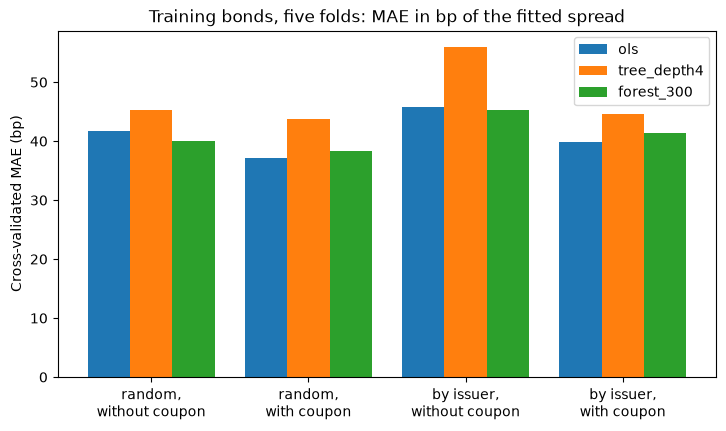

In [29]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
groups = [("cv", "without coupon"), ("cv", "with coupon"), ("cv_by_issuer", "without coupon"), ("cv_by_issuer", "with coupon")]
labels = ["random,\nwithout coupon", "random,\nwith coupon", "by issuer,\nwithout coupon", "by issuer,\nwith coupon"]
for k, name in enumerate(["ols", "tree_depth4", "forest_300"]):
    heights = [scores[(name, features, rows)]["mae_bp"].mean() for rows, features in groups]
    ax.bar(np.arange(4) + (k - 1) * 0.27, heights, width=0.27, label=name)
ax.set_xticks(np.arange(4))
ax.set_xticklabels(labels)
ax.set_ylabel("Cross-validated MAE (bp)")
ax.set_title("Training bonds, five folds: MAE in bp of the fitted spread")
ax.legend()
plt.show()

* The forest's bar is the lowest in the two groups without coupon, and only just in the second of them. With coupon, OLS's bar is the lowest. Splitting by issuer raises every bar; adding coupon lowers every bar, OLS's most.

## 5.9 What the Model Shows, and Where It Fails

Q. Where does the forest miss? Take each bond's out-of-fold fitted spread, without coupon, from the random folds.

In [30]:
# each bond's fitted value from the fold model that did not see it: the same five folds, the same models
fitted_forest = cross_val_predict(three_models(NUM_NO)["forest_300"], X, y, cv=folds, n_jobs=1)
fitted_ols = cross_val_predict(three_models(NUM_NO)["ols"], X, y, cv=folds, n_jobs=1)

# the residual: OAS minus the fitted spread, in bp
grade = train["rating"].map(ratings.set_index("rating")["grade"]).rename("grade")
residuals = pd.DataFrame({"forest_300": train["oas"] - np.exp(fitted_forest), "ols": train["oas"] - np.exp(fitted_ols)})
print("MAE in bp by grade, out of fold")
print(residuals.abs().groupby(grade).mean().round(1).to_string())

# the five largest misses of the forest
worst = residuals["forest_300"].abs().sort_values(ascending=False).index[:5]
print(train.loc[worst, ["rating", "oas"]].assign(forest_fitted_bp=np.exp(fitted_forest[train.index.get_indexer(worst)]).round(1)).to_string())
print(f"widest OAS in the training bonds {train['oas'].max():,} bp; widest fitted spread: forest {np.exp(fitted_forest).max():.1f} bp, OLS {np.exp(fitted_ols).max():.1f} bp")

MAE in bp by grade, out of fold
                  forest_300   ols
grade                             
High Yield              79.9  85.9
Investment Grade        19.2  18.6
    rating   oas  forest_fitted_bp
386      B  2074             586.8
789     B-  1718             674.4
47       B  1446             446.6
365   CCC+  1551             579.9
533      B   933             394.9
widest OAS in the training bonds 2,074 bp; widest fitted spread: forest 915.0 bp, OLS 1025.9 bp


* The forest misses high yield bonds by 79.9 bp on average and investment grade bonds by 19.2 bp (OLS: 85.9 and 18.6). The five largest misses, all of them high yield, make up 20 percent of the forest's total absolute error on 615 bonds.
* The widest bond, rated B at 2,074 bp, gets a fitted spread of 586.8 bp from the forest and 373.1 bp from OLS. The forest's widest fitted spread anywhere is 915.0 bp: an average of leaf means cannot reach beyond the bonds the trees were fitted on, and averaging pulls it further in.

**What it shows.** On 615 training bonds of a synthetic benchmark, scored by five folds, a 300-tree forest of log OAS on the rating's number, sector, duration, years, and amount misses by 40.0 bp on average, against 41.7 bp for Course 4's straight-line model on the same information and 45.2 bp for one depth-4 tree. Averaging trees beats one tree by a wide margin and beats the straight line by a little, on 3 of 5 folds. With coupon, which partly restates the spread in this file, the straight line misses by less (37.2 against 38.3 bp).

**Where it fails.**

* **New issuers.** Split by issuer, every model misses by more, and the forest's lead without coupon shrinks to 0.5 bp. Part of what a flexible model learns at random is each issuer's own level, which does not carry over.
* **Wide spreads.** High yield errors are about 4 times investment grade errors. A model fitted in logs misses by a share of the spread, so the same share is more bp on a wider spread. And the generator picked six bonds rated B or worse at random and multiplied their spreads by 2.5 to 4 after their coupons were set: their rating, sector, years, and size carry nothing of that draw.
* **The edges.** A forest's fitted spread is an average of training spreads. It cannot go beyond the widest or tightest bond it was fitted on, where a straight line can.
* **The folds.** Fold MAEs differ by 31.2 bp from the easiest fold to the hardest. Differences between models of one or two bp are at the edge of what these 615 bonds can show.
* **The form of the input.** The forest was behind OLS on Course 4's one-hot columns and ahead on the rating's number. A comparison of models is also a comparison of how each was given the data.

**What the data cannot support.** The bonds and spreads are synthetic: the models recover part of a recipe the course wrote, and nothing here describes a real market, a real issuer, or how spreads behave anywhere else. The file is one date. A fitted spread is the model's spread for a bond with these characteristics, and a residual is the part of a spread the model misses; neither is a fair value, and nothing here is a basis for a decision about any bond.

**What was not tested.** Forest settings (leaf size, columns per split; exercise 1 tries one), the generator's capped maturity term as a feature (week 3), boosted trees (week 2, day 7 on these bonds), and Course 4's 206 test bonds, which stay closed.

## Excel Side by Side

Excel has no worksheet function for a regression tree, a random forest, or cross-validation. What Excel can do is the arithmetic of the scores: turn a fitted log spread back into bp, average the absolute misses, summarise five fold scores, and compute an R-squared from two pasted columns. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-05), on the 615 training bonds with Python's fitted values pasted in as values.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| A fitted log spread in bp | `np.exp(fitted_forest)` | `=EXP(C2)`, filled down | equal to numpy |
| MAE in bp of the forest's out-of-fold fitted spreads | `mae_bp_from_logs(y, fitted_forest)` | `=AVERAGE(ABS(EXP(B2:B616)-EXP(C2:C616)))` | 39.9947 |
| Mean of the five fold MAEs | `table["mae_bp"].mean()` | `=AVERAGE(F2:F6)` | 39.9947 |
| Their spread, the fold sd | `table["mae_bp"].std(ddof=0)` | `=STDEV.P(F2:F6)` | 11.6052 |
| The same with n - 1 | `table["mae_bp"].std(ddof=1)` | `=STDEV.S(F2:F6)` | 12.9750 |
| Out-of-bag R-squared | `forest.oob_score_` | `=1-SUMXMY2(B2:B616,C2:C616)/DEVSQ(B2:B616)` | 0.8816 |
| Out-of-bag MAE in bp | `oob_mae` | `=AVERAGE(ABS(EXP(B2:B616)-EXP(C2:C616)))` on the out-of-bag column | 41.0272 |

**The MAE in bp.** With `log_oas` in B2:B616 and the forest's out-of-fold fitted log spread in C2:C616, `=EXP(C2)` in D2, filled down, is the fitted spread in bp. `=AVERAGE(ABS(EXP(B2:B616)-EXP(C2:C616)))` does the whole metric in one cell: `EXP` of each column, the difference, `ABS`, and `AVERAGE` over the 615 rows. In current Excel it calculates as an array formula when typed normally. Because the five folds hold 123 bonds each, this pooled number equals the mean of the five fold MAEs, and Excel returned the same value both ways.

**The fold sd.** With the five fold MAEs in F2:F6, `=STDEV.P(F2:F6)` divides by 5 and equals the `ddof=0` number the notebook prints; `=STDEV.S(F2:F6)` divides by 4 and comes out larger. The course prints `STDEV.P`'s number.

**The out-of-bag R-squared.** With `oob_prediction_` pasted in C, `=1-SUMXMY2(B2:B616,C2:C616)/DEVSQ(B2:B616)` is one minus the sum of squared misses over the sum of squared deviations from the mean, the definition of R-squared that scikit-learn uses, and it equals `oob_score_`.

Q. Do Excel's numbers equal Python's?

In [31]:
# Excel's numbers, from the course's Excel check, beside Python's for the same bonds
fold_table = scores[("forest_300", "without coupon", "cv")]["mae_bp"]
excel = {"MAE in bp, out-of-fold forest": 39.99471910350997,
         "mean of the five fold MAEs": 39.99471910350995,
         "fold sd (STDEV.P)": 11.605219233324675,
         "out-of-bag R-squared": 0.8815748625944283,
         "out-of-bag MAE in bp": 41.02715046089876}
python = {"MAE in bp, out-of-fold forest": mae_bp_from_logs(y, fitted_forest),
          "mean of the five fold MAEs": fold_table.mean(),
          "fold sd (STDEV.P)": fold_table.std(ddof=0),
          "out-of-bag R-squared": forest.oob_score_,
          "out-of-bag MAE in bp": oob_mae}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["within 1e-12"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-12
side_by_side

,Excel,Python,within 1e-12
"MAE in bp, out-of-fold forest",39.994719,39.994719,True
mean of the five fold MAEs,39.994719,39.994719,True
fold sd (STDEV.P),11.605219,11.605219,True
out-of-bag R-squared,0.881575,0.881575,True
out-of-bag MAE in bp,41.027150,41.027150,True


* Every number matches within 1e-12. The models are Python's; the scores are arithmetic Excel does just as well once the fitted values are on a sheet.

## Save the Day with Git

Today's work folder gets its own repository, as every day's does. The module goes in first, then the experiment log in two commits: the random folds, then the folds by issuer. The last commit of week 1 gets a name, a **tag**, so it can be found again without its hash.

Q. Make the work folder a repository.

In [32]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [33]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course5_05_eemxnj_k and nowhere else


Q. Tell Git which files never to track, and commit the module as it stands at the end of today.

In [34]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [35]:
# the data files are copies of the course's files and stay untracked
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py test_ensemblekit.py
!git -C "{work}" commit -q -m "ensemblekit through day 5: Course 4's training bonds and the out-of-fold threshold, 21 tests"
!git -C "{work}" status --short

?? benchmark.csv
?? credit_card_default.csv
?? ratings.csv


Q. Write the random-fold rows of the experiment log to `results.csv` and commit them.

In [36]:
# Course 5's regression log: model, features, rows, mae_bp, r2; rows is cv (random folds) or cv_by_issuer
log_columns = ["model", "features", "rows", "mae_bp", "r2"]
random_rows = results[results["rows"] == "cv"][log_columns]
random_rows.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,features,rows,mae_bp,r2
ols,without coupon,cv,41.7166,0.8794
tree_depth4,without coupon,cv,45.2143,0.8625
forest_300,without coupon,cv,39.9947,0.8881
ols,with coupon,cv,37.1878,0.8972
tree_depth4,with coupon,cv,43.7846,0.8666
forest_300,with coupon,cv,38.2882,0.8987



In [37]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: OLS, a depth-4 tree, and a 300-tree forest on log OAS, 5-fold MAE in bp"

Q. Add the rows from the folds split by issuer, commit, and tag the commit `week1`.

In [38]:
# all twelve rows: the six above, then the six by issuer
results[log_columns].sort_values("rows", kind="stable").to_csv("results.csv", index=False, float_format="%.4f",
                                                               lineterminator="\n")
print(f"results.csv now has {len(results)} rows")

results.csv now has 12 rows


In [39]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: the same models with the folds split by issuer"
!git -C "{work}" tag week1
!git -C "{work}" log --oneline --decorate

c9ced17 (HEAD -> main, tag: week1) Experiment log: the same models with the folds split by issuer
f007d6e Experiment log: OLS, a depth-4 tree, and a 300-tree forest on log OAS, 5-fold MAE in bp
2e8e10f ensemblekit through day 5: Course 4's training bonds and the out-of-fold threshold, 21 tests


* `git tag week1` names the current commit. `--decorate` shows the name beside it, with `HEAD -> main`, the branch you are on.

Q. What changed in `results.csv` in the tagged commit?

In [40]:
# week1~1 is the commit before the tag; the diff shows what the tagged commit added
!git -C "{work}" diff week1~1 week1 -- results.csv

diff --git a/results.csv b/results.csv
index a390b0a..862da57 100644
--- a/results.csv
+++ b/results.csv
@@ -5,3 +5,9 @@ forest_300,without coupon,cv,39.9947,0.8881
 ols,with coupon,cv,37.1878,0.8972
 tree_depth4,with coupon,cv,43.7846,0.8666
 forest_300,with coupon,cv,38.2882,0.8987
+ols,without coupon,cv_by_issuer,45.7623,0.8117
+tree_depth4,without coupon,cv_by_issuer,55.9545,0.7893
+forest_300,without coupon,cv_by_issuer,45.2195,0.8506
+ols,with coupon,cv_by_issuer,39.7718,0.8485
+tree_depth4,with coupon,cv_by_issuer,44.6318,0.8324
+forest_300,with coupon,cv_by_issuer,41.4231,0.8689


* `week1~1` means "one commit before `week1`", so the diff shows exactly what the last commit changed: six lines added, each a model scored with the folds split by issuer, and nothing else touched. A tag works anywhere a hash does, in `git diff`, `git show`, or `git log`.

## Bring It Home

Add today's two functions to your own `my_bondmath` folder, and tag the end of week 1. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder and copy in the two benchmark files today's tests read. Like the card file, they are copies of the course's data and are never committed.

```powershell
Set-Location "$HOME\projects\my_bondmath"
Copy-Item "$HOME\projects\python-fixed-income\data\benchmark.csv" .
Copy-Item "$HOME\projects\python-fixed-income\data\ratings.csv" .
```

**Step 2.** Paste the code of today's two `%%writefile -a ensemblekit.py` cells (sections 5.1 and 5.2), without their first lines, at the end of `ensemblekit.py`, and the two `%%writefile -a test_ensemblekit.py` cells at the end of `test_ensemblekit.py`. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_ensemblekit.py
```

The last line says `21 passed`.

**Step 4.** Read the change, commit the code, and tag the end of the week.

```powershell
git diff --stat
git add ensemblekit.py test_ensemblekit.py
git commit -m "ensemblekit through day 5: Course 4's training bonds and the out-of-fold threshold, 21 tests"
git tag week1
git log --oneline --decorate -3
```

**In Colab**, download `ensemblekit.py` and `test_ensemblekit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Rebuild Course 4's training bonds with `course4_bench_rows`, with its test bonds closed.
* Say what a regression tree's leaf gives, and why a depth-4 tree gives at most 16 fitted spreads.
* Read `oob_score_` for a regressor as R-squared, and check it against `r2_score` on `oob_prediction_`.
* Choose a threshold for recall 0.70 from out-of-fold probabilities on the training rows with `oof_threshold`, and report it on rows that took no part.
* Compare models on the same bonds and folds by MAE in bp, read the fold sd before the gap, and compare fold by fold.
* Give a forest its inputs in a form a tree can use, and measure what that is worth.
* Split folds by issuer with `GroupKFold`, and say which question each split answers.
* Write what a model shows and where it fails, and tag a commit.

Next week, day 6: boosting, starting with AdaBoost, where trees are trained one after another instead of side by side.

## Exercises

The exercises use Course 4's 615 training bonds of the synthetic benchmark, scored by the course's five folds; Course 4's 206 test bonds stay closed. Every fitted value is the model's spread for a bond with these characteristics. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the training bonds, defines the case study's two pipelines and its metric, scores OLS and the forest without coupon, and defines `check`, a small function that marks your answers.

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# the benchmark and Course 4's training bonds (synthetic: invented issuers, generated spreads)
bench = pd.read_csv("benchmark.csv")
ratings = pd.read_csv("ratings.csv")
train = ensemblekit.course4_bench_rows(bench, ratings)
X = train[["rating", "sector", "score", "duration", "years", "coupon", "amount_bn"]]
y = train["log_oas"]
NUM_NO = ["duration", "years", "amount_bn"]
folds = mlkit.cv_folds("regression")


def ols_pipeline(model, numbers):
    """Course 4 day 5's pipeline: rating and sector as indicators (reference A and Consumer), the numbers scaled."""
    encode = ColumnTransformer([("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), ["rating", "sector"]),
                                ("numbers", StandardScaler(), numbers)])
    return Pipeline([("encode", encode), ("model", model)])


def tree_pipeline(model, numbers):
    """For trees: sector as indicators, the rating as its number (score), and the numbers as they are."""
    encode = ColumnTransformer([("sector", OneHotEncoder(handle_unknown="ignore"), ["sector"]),
                                ("numbers", "passthrough", ["score"] + numbers)])
    return Pipeline([("encode", encode), ("model", model)])


def mae_bp_from_logs(log_true, log_fitted):
    """Mean absolute error in bp, after turning both log spreads back into bp with exp."""
    return float(np.mean(np.abs(np.exp(log_true) - np.exp(log_fitted))))


SCORING = {"mae_bp": make_scorer(mae_bp_from_logs), "r2": "r2"}

# the case study's two models without coupon, on the random folds: today's experiment log, in short
scores = {}
for name, model in [("ols", ols_pipeline(LinearRegression(), NUM_NO)),
                    ("forest_300", tree_pipeline(RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=1), NUM_NO))]:
    folds_out = cross_validate(model, X, y, cv=folds, scoring=SCORING, n_jobs=1)
    scores[(name, "without coupon", "cv")] = pd.DataFrame({"mae_bp": folds_out["test_mae_bp"], "r2": folds_out["test_r2"]})
results = pd.DataFrame([{"model": k[0], "features": k[1], "rows": k[2], "mae_bp": t["mae_bp"].mean(), "r2": t["r2"].mean()}
                        for k, t in scores.items()])
print(results.round(4).to_string())


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

        model        features rows   mae_bp      r2
0         ols  without coupon   cv  41.7166  0.8794
1  forest_300  without coupon   cv  39.9947  0.8881


### Exercise 1

Q. Score the case study's forest without coupon, with one change: each split may try only a third of the columns (`max_features=0.33`). Use `tree_pipeline`, `NUM_NO`, `folds`, and `SCORING` from the setup cell, and store the mean of the five fold MAEs in bp in **ex1_mae**.

In [42]:
ex1_mae = ...

In [43]:
check("Exercise 1 the forest with max_features=0.33", ex1_mae, 42.36379983674395)

Exercise 1 the forest with max_features=0.33: not attempted yet


### Exercise 2

Q. Repeat the comparison on the investment grade bonds only (`train["score"] <= 10`, BBB- and better), with the same folds: store the mean fold MAE in bp of OLS in **ex2_ols** and of the forest in **ex2_forest**, both without coupon.

In [44]:
ex2_ols = ...
ex2_forest = ...

In [45]:
check("Exercise 2 OLS on investment grade", ex2_ols, 18.320090638253863)
check("Exercise 2 the forest on investment grade", ex2_forest, 19.439510287721625)

Exercise 2 OLS on investment grade: not attempted yet
Exercise 2 the forest on investment grade: not attempted yet


### Exercise 3

Q. Add a function to your module. `bp_table(results)` takes an experiment log with the columns `model`, `features`, `rows`, and `mae_bp`, and returns one row per model and one column per features-and-rows pair, named like `"without coupon, cv"`, holding the MAE in bp rounded to 1 decimal. It raises `ValueError` if a column is missing or a model appears twice with the same features and rows. Write the docstring first. Then add `test_bp_table_hand` with a small log you write by hand. Run pytest, reload the module, and store `ensemblekit.bp_table(results).loc["forest_300", "without coupon, cv"]` in **ex3_forest**.

Write the function in the cell that starts with `%%writefile -a ensemblekit.py` and the test in the one that starts with `%%writefile -a test_ensemblekit.py`, and run each of those cells once.

In [46]:
%%writefile -a ensemblekit.py


# Exercise 3: write bp_table(results) below this line

Appending to ensemblekit.py


In [47]:
%%writefile -a test_ensemblekit.py


# Exercise 3: write test_bp_table_hand() below this line

Appending to test_ensemblekit.py


In [48]:
# run pytest, reload the module, then call your function
ex3_forest = ...

In [49]:
check("Exercise 3 bp_table for the forest", ex3_forest, 40.0)

Exercise 3 bp_table for the forest: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that cross-validates the case study's forest, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Cross-validated MAE in bp of the 300-tree forest, on Course 4's 615 training bonds only.

    Builds score, log_oas, years, and amount_bn as course4_bench_rows does, keeps Course 4's training bonds (its
    206 test bonds stay closed), and scores the forest without coupon by five folds, mlkit.cv_folds("regression").
    Returns (mae_bp, rows): the mean of the five fold MAEs in bp, and the bonds that were scored.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns an MAE in bp that looks like the case study's, and contains one bug.

In [50]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def forest_cv_mae(bench, ratings):
    """Cross-validated MAE in bp of the 300-tree forest, on Course 4's 615 training bonds only.

    Builds score, log_oas, years, and amount_bn as course4_bench_rows does, keeps Course 4's training bonds (its
    206 test bonds stay closed), and scores the forest without coupon by five folds, mlkit.cv_folds("regression").
    Returns (mae_bp, rows): the mean of the five fold MAEs in bp, and the bonds that were scored.
    """
    # the rating's number, the log spread, years to maturity, and size, as the course builds them
    rows = bench.merge(ratings[["rating", "score"]], on="rating", how="left")
    rows["log_oas"] = np.log(rows["oas"])
    rows["years"] = (pd.to_datetime(rows["maturity"]) - pd.to_datetime(rows["as_of_date"])).dt.days / 365.25
    rows["amount_bn"] = rows["amount_outstanding"] / 1e9
    # cross-validation keeps every score honest: each fold is scored by a forest that never saw it
    forest = tree_pipeline(RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=1), NUM_NO)
    scores = cross_validate(forest, rows, rows["log_oas"], cv=mlkit.cv_folds("regression"), scoring=SCORING, n_jobs=1)
    return scores["test_mae_bp"].mean(), rows

Q. Before you run the next cell: how many bonds will `forest_cv_mae` score? The docstring says Course 4's 615 training bonds.

In [51]:
ai_mae, ai_rows = forest_cv_mae(bench, ratings)
print(f"MAE {ai_mae:.1f} bp on {len(ai_rows)} bonds")

MAE 38.1 bp on 821 bonds


Q. Test the function against its docstring before you trust it.

In [52]:
# the test, written from the docstring before the code is trusted
ai_mae, ai_rows = forest_cv_mae(bench, ratings)
closed = set(bench["cusip"]) - set(train["cusip"])

# 1. the bonds scored are exactly Course 4's training bonds
assert set(ai_rows["cusip"]) == set(train["cusip"]), f"{len(ai_rows)} bonds scored, not Course 4's {len(train)} training bonds"
# 2. no closed test bond among them
assert not set(ai_rows["cusip"]) & closed, "a closed test bond was scored"
print(f"forest_cv_mae: {len(ai_rows)} bonds, MAE {ai_mae:.1f} bp")

AssertionError: 821 bonds scored, not Course 4's 615 training bonds

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's MAE, `forest_cv_mae(bench, ratings)[0]`, in **ex4_mae**.

In [53]:
# fix the function above and run the test again, then store the answer
ex4_mae = ...

In [54]:
check("Exercise 4 the fixed function's MAE", ex4_mae, 39.99471910350995)

Exercise 4 the fixed function's MAE: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```